# Pairs Trading Strategy — Baseline Template

**Student Name**: [Your Name]

**Project**: LFC MarketView Pairs Trading

**Goal**: Build a stat arb strategy — find cointegrated pairs, trade Z-score divergences

---

## Structure
1. Pair Selection & Cointegration (Week 1)
2. Signal Generation & Strategy (Week 2)
3. Backtest & Performance (Week 3)

---

## Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from statsmodels.tsa.stattools import coint, adfuller
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline
print('Libraries loaded')

Libraries loaded


---
## Week 1: Pair Selection & Cointegration

**Goal**: Find statistically valid pairs using cointegration tests

In [2]:
# Candidate pairs to test
PAIRS = [
    ('KO',   'PEP'),   # Coca-Cola vs Pepsi
    ('XOM',  'CVX'),   # ExxonMobil vs Chevron
    ('GS',   'JPM'),   # Goldman vs JPMorgan
    ('DAL',  'UAL'),   # Delta vs United Airlines
    ('MSFT', 'GOOGL'), # Microsoft vs Alphabet
]

START_DATE = '2018-01-01'
END_DATE   = '2026-03-01'

print(f'Pairs to test: {len(PAIRS)}')
print(f'Date range: {START_DATE} to {END_DATE}')

Pairs to test: 5
Date range: 2018-01-01 to 2026-03-01


In [4]:
# Download all tickers
all_tickers = list(set([t for pair in PAIRS for t in pair]))
price_data = {}

for ticker in all_tickers:
    temp = yf.download(ticker, start=START_DATE, end=END_DATE,
                       progress=False, auto_adjust=True)
    if not temp.empty:
        if isinstance(temp.columns, pd.MultiIndex):
            price_data[ticker] = temp['Close'][ticker]
        else:
            price_data[ticker] = temp['Close']
        print(f'YES {ticker}')

prices = pd.DataFrame(price_data).dropna()
print(f'\nShape: {prices.shape}')
prices.head()

YES KO
YES JPM
YES GS
YES DAL
YES CVX
YES MSFT
YES UAL
YES PEP
YES XOM
YES GOOGL

Shape: (2050, 10)


,KO,JPM,GS,DAL,CVX,MSFT,UAL,PEP,XOM,GOOGL
Date,,,,,,,,,,
2018-01-02,35.492725,86.340897,213.144211,51.925335,89.452385,78.870338,68.940002,92.421173,58.580414,53.258095
2018-01-03,35.414799,86.428879,211.160095,50.964432,90.104446,79.237419,68.489998,92.178505,59.730942,54.166729
2018-01-04,35.913597,87.667023,214.111313,50.964432,89.823975,79.934822,69.260002,92.632553,59.813648,54.377136
2018-01-05,35.905796,87.104233,213.019180,51.220673,89.676750,80.925873,69.360001,92.898712,59.765404,55.098186
2018-01-08,35.851257,87.232864,209.926285,50.040127,90.118477,81.008430,68.510002,92.366386,60.034081,55.292721


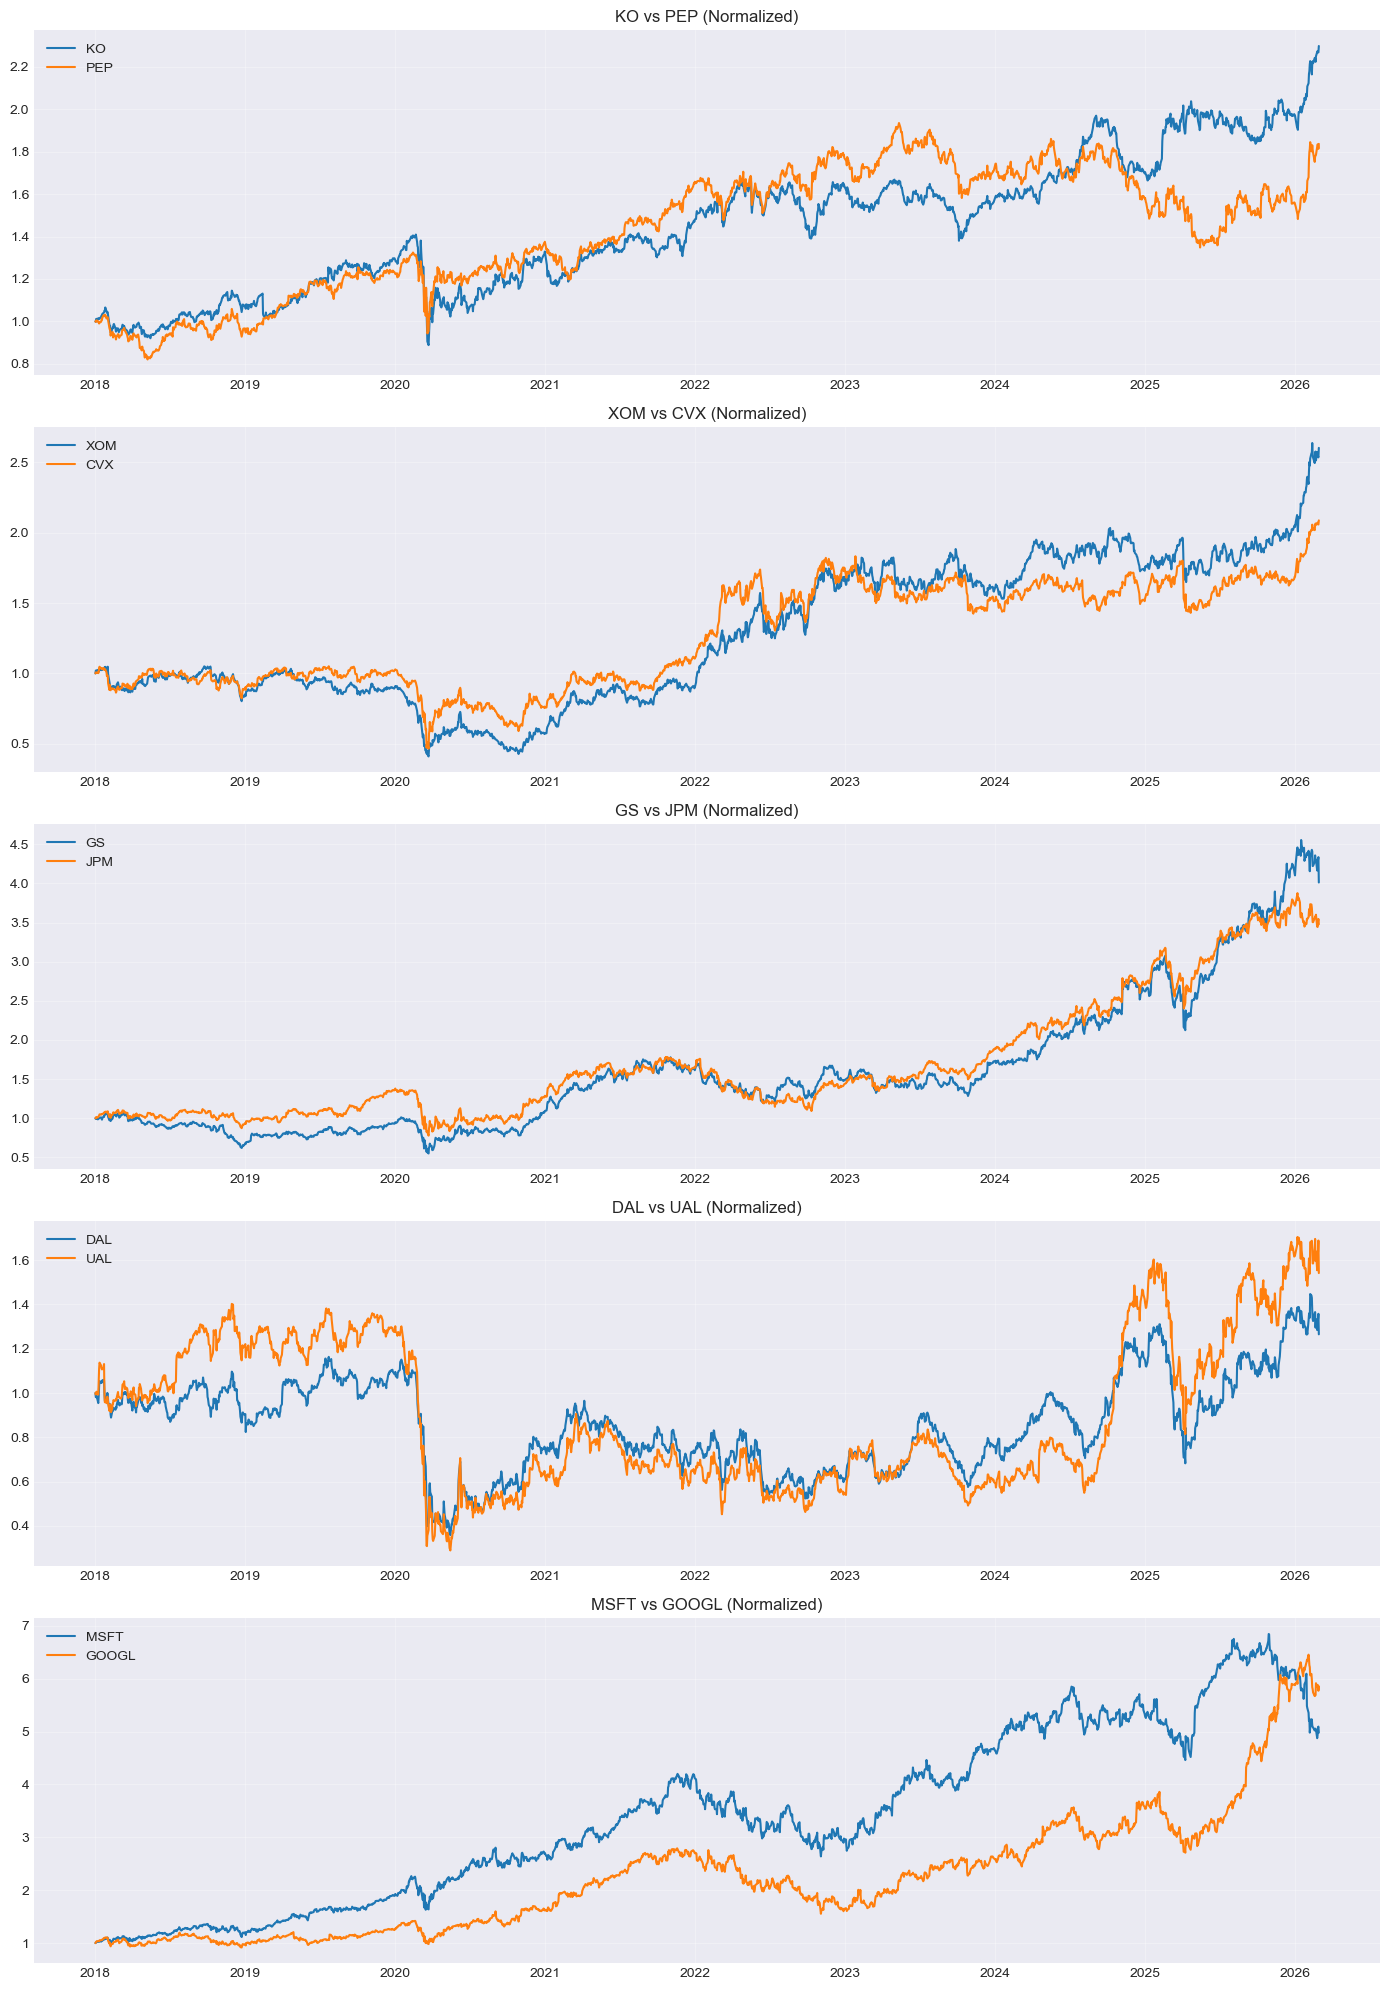

In [5]:
# Plot normalized prices for each pair
fig, axes = plt.subplots(len(PAIRS), 1, figsize=(14, 4 * len(PAIRS)))

for i, (stock_a, stock_b) in enumerate(PAIRS):
    norm_a = prices[stock_a] / prices[stock_a].iloc[0]
    norm_b = prices[stock_b] / prices[stock_b].iloc[0]
    axes[i].plot(norm_a.index, norm_a, label=stock_a, linewidth=1.5)
    axes[i].plot(norm_b.index, norm_b, label=stock_b, linewidth=1.5)
    axes[i].set_title(f'{stock_a} vs {stock_b} (Normalized)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Run cointegration test on all pairs
print('Cointegration Test Results (Engle-Granger)\n')
print(f'{"Pair":<20} {"p-value":<12} {"Cointegrated?"}') 
print('-' * 45)

valid_pairs = []
for stock_a, stock_b in PAIRS:
    score, p_value, _ = coint(prices[stock_a], prices[stock_b])
    is_coint = 'YES' if p_value < 0.05 else 'NO'
    if p_value < 0.05:
        valid_pairs.append((stock_a, stock_b))
    print(f'{stock_a}/{stock_b:<15} {p_value:<12.4f} {is_coint}')

print(f'\nValid pairs for trading: {valid_pairs}')

Cointegration Test Results (Engle-Granger)

Pair                 p-value      Cointegrated?
---------------------------------------------
KO/PEP             0.9738       NO
XOM/CVX             0.1516       NO
GS/JPM             0.5243       NO
DAL/UAL             0.0279       YES
MSFT/GOOGL           0.9809       NO

Valid pairs for trading: [('DAL', 'UAL')]


In [8]:
# Calculate hedge ratio using OLS regression for first valid pair
if valid_pairs:
    stock_a, stock_b = valid_pairs[0]
    X = sm.add_constant(prices[stock_b])
    model = sm.OLS(prices[stock_a], X).fit()
    beta = model.params[stock_b]
    print(f'Pair: {stock_a} / {stock_b}')
    print(f'Hedge ratio (β): {beta:.4f}')
    print(f'Interpretation: For every 1 share of {stock_a}, short {beta:.2f} shares of {stock_b}')

Pair: DAL / UAL
Hedge ratio (β): 0.4295
Interpretation: For every 1 share of DAL, short 0.43 shares of UAL


---
## Week 2: Signal Generation & Strategy Logic

**Goal**: Calculate Z-score signals and code entry/exit rules

**TODO**: Implement the strategy below

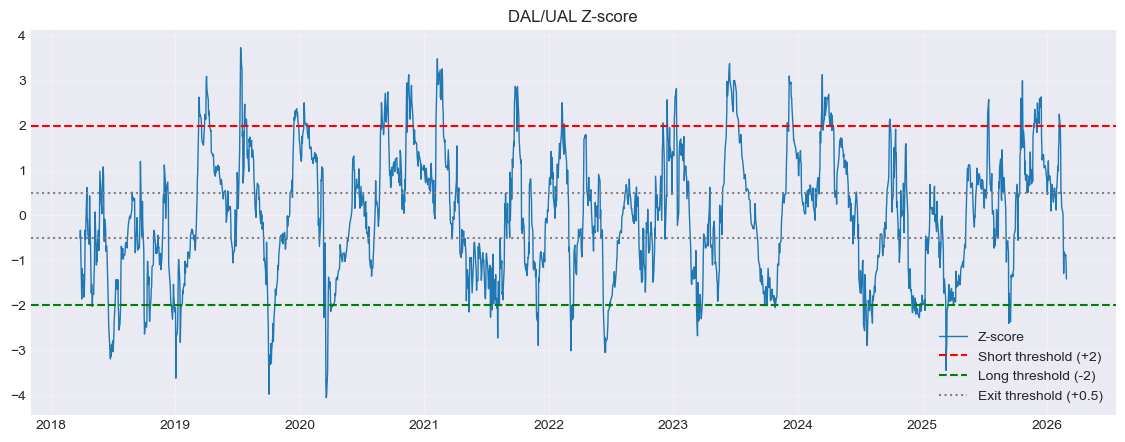

In [9]:
# Calculate spread and Z-score for first valid pair
if valid_pairs:
    stock_a, stock_b = valid_pairs[0]

    # Spread
    spread = prices[stock_a] - beta * prices[stock_b]

    # Rolling Z-score (60-day window)
    window = 60
    spread_mean = spread.rolling(window).mean()
    spread_std  = spread.rolling(window).std()
    z_score = (spread - spread_mean) / spread_std

    # Plot Z-score with thresholds
    plt.figure(figsize=(14, 5))
    plt.plot(z_score.index, z_score, label='Z-score', linewidth=1)
    plt.axhline(2.0,  color='red',   linestyle='--', label='Short threshold (+2)')
    plt.axhline(-2.0, color='green', linestyle='--', label='Long threshold (-2)')
    plt.axhline(0.5,  color='gray',  linestyle=':',  label='Exit threshold (+0.5)')
    plt.axhline(-0.5, color='gray',  linestyle=':')
    plt.title(f'{stock_a}/{stock_b} Z-score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [11]:
# TODO (Student): Implement trading signal logic
#
# Entry rules:
#   Z > +2.0  → Short A, Long B
#   Z < -2.0  → Long A, Short B
#
# Exit rules:
#   |Z| < 0.5 → Close position
#   |Z| > 3.5 → Stop-loss, close position
#
# Hint: use np.where() or a for loop over dates
# Store: entry_date, exit_date, direction, P&L

print('Signal logic: Student work here')

Signal logic: Student work here


---
## Week 3: Backtest & Performance Analysis

**TODO**: Calculate metrics and create all visualizations

In [12]:
# TODO (Student): Calculate performance metrics
#
# - CAGR
# - Sharpe Ratio
# - Max Drawdown
# - Win Rate (% of trades profitable)
# - Average holding period
# - Number of trades

print('Performance metrics: Student work here')

Performance metrics: Student work here


Add your strategy cumulative returns to the chart below


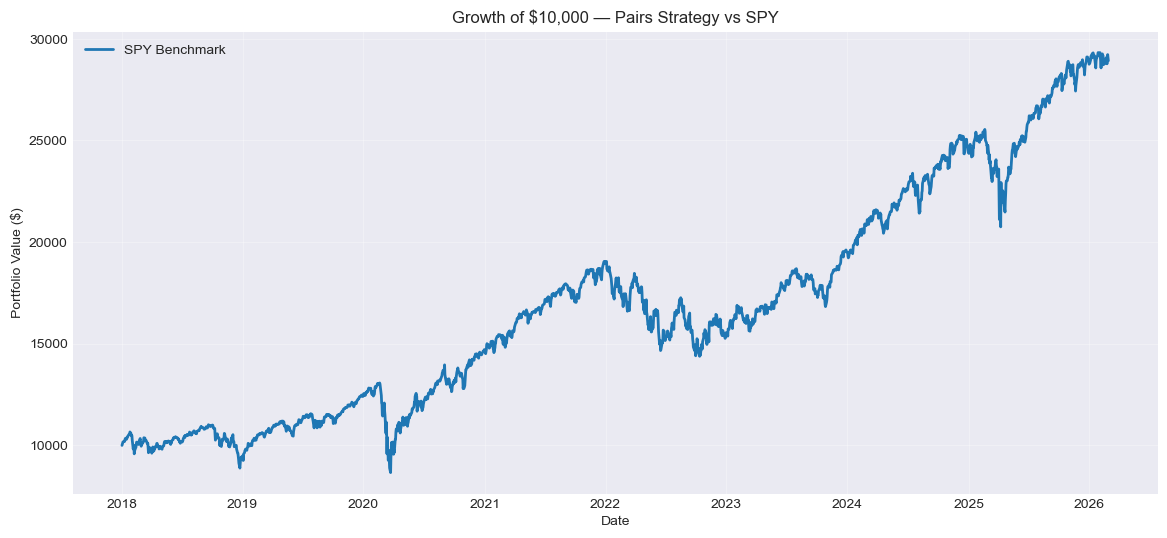

In [13]:
# TODO (Student): Growth of $10,000 chart vs SPY
# Download SPY as benchmark
spy = yf.download('SPY', start=START_DATE, end=END_DATE,
                  progress=False, auto_adjust=True)['Close']
if isinstance(spy.columns if hasattr(spy, 'columns') else pd.Index([]), pd.MultiIndex):
    spy = spy['SPY']
spy_returns = spy.pct_change().fillna(0)
spy_growth  = 10000 * (1 + spy_returns).cumprod()

print('Add your strategy cumulative returns to the chart below')

# Placeholder chart
plt.figure(figsize=(14, 6))
plt.plot(spy_growth.index, spy_growth, label='SPY Benchmark', linewidth=2)
plt.title('Growth of $10,000 — Pairs Strategy vs SPY')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
# TODO (Student): Performance table (fill in your results)
performance = pd.DataFrame({
    'Metric':          ['CAGR', 'Sharpe', 'Max Drawdown', 'Win Rate', 'Avg Hold (days)', 'Num Trades'],
    'KO/PEP':          ['TBD', 'TBD', 'TBD', 'TBD', 'TBD', 'TBD'],
    'XOM/CVX':         ['TBD', 'TBD', 'TBD', 'TBD', 'TBD', 'TBD'],
    'SPY Benchmark':   ['TBD', 'TBD', 'TBD', '—',   '—',   '—'],
})
performance

,Metric,KO/PEP,XOM/CVX,SPY Benchmark
0,CAGR,TBD,TBD,TBD
1,Sharpe,TBD,TBD,TBD
2,Max Drawdown,TBD,TBD,TBD
3,Win Rate,TBD,TBD,—
4,Avg Hold (days),TBD,TBD,—
5,Num Trades,TBD,TBD,—


---
## Conclusions

**TODO**: Write your analysis here

### Best Performing Pair
[Answer]

### When the Strategy Works
[Answer]

### When the Strategy Fails
[Answer]

### Limitations
[Answer]

### Potential Improvements
[Answer]

---
**Completed by**: [Your Name] | **Date**: [Date]